In [1]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

# Установка зависимостей
!pip install centpy pandas matplotlib seaborn

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 283 (delta 15), reused 39 (delta 14), pack-reused 215 (from 1)
Receiving objects: 100% (283/283), 26.48 MiB | 18.66 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [2]:
!git clone https://github.com/tumaer/JAXFLUIDS.git
!pip install -e JAXFLUIDS

Cloning into 'JAXFLUIDS'...
remote: Enumerating objects: 2533, done.
remote: Counting objects: 100% (659/659), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 2533 (delta 523), reused 494 (delta 456), pack-reused 1874 (from 2)
Receiving objects: 100% (2533/2533), 13.18 MiB | 17.39 MiB/s, done.
Resolving deltas: 100% (1458/1458), done.
Obtaining file:///content/diploma_centpy_parallelization_py/jax_centpy/JAXFLUIDS
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jaxfluids (pyproject.toml) ... done
  Created wheel for jaxfluids: filename=jaxfluids-0.2.1-0.editable-py3-none-any.whl size=4993 sha256=6debf0089fba56eb9147f622bbbc582638d5a28a708bb9fba91d32a6c876ad24
  Stored in directory: /tmp/pip-ephem-wheel-cache-49y4o3xe/wheels/0d/f5/f7/36c7ba3191fe532ed59d9727c10bd83ddce132ae2a04111c95

In [3]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files
from typing import Callable, NamedTuple

from core import Pars2d, Equation2d, Pars1d, Equation1d
from solver import Solver1d, FastSolver1d
from boundaries import periodic_bc_2d, neumann_bc_2d, dirichlet_riemann_bc_2d
from equations import make_euler_riemann_2d, make_euler_isentropic_vortex_2d
from schemes import compute_rhs_sd2_2d
from limiters import monotonized_central, minmod
from richardson import self_convergence_analysis

In [4]:
def make_modified_sod(gamma=1.4, alpha: float = 0.1) -> Equation1d:
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        E = q[..., 2]
        return (gamma - 1.0) * (E - 0.5 * rho * u**2)

    def flux(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        E = q[..., 2]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = jnp.maximum(compute_pressure(q), 1e-10)
        c = jnp.sqrt(gamma * p / rhosafe)
        a = jnp.abs(u) + c
        return a[..., None]

    def initial_data(x):
        # Невозмущенный газ
        rho_0, p_0 = 1.0, 1.0
        # alpha = 0.1 # Коэффициент понижения плотности в каверне

        # Состояние за ударной волной (по Ренкину-Гюгонио для M=2)
        rho_R = 2.66666666667
        p_R = 4.5
        u_R = -1.47901994677

        # Границы областей
        x_0 = 0.3
        x_1 = 0.5
        x_sw = 0.8

        # Кусочно-постоянное распределение плотности
        rho = jnp.where(x < x_0, rho_0,
                jnp.where(x <= x_1, alpha * rho_0,
                jnp.where(x < x_sw, rho_0, rho_R)))

        # Распределение скорости (движется только газ за фронтом УВ)
        u = jnp.where(x < x_sw, 0.0, u_R)

        # Распределение давления
        p = jnp.where(x < x_0, p_0,
                jnp.where(x <= x_1, p_0,
                jnp.where(x < x_sw, p_0, p_R)))

        E = p / (gamma - 1.0) + 0.5 * rho * u**2
        return jnp.stack([rho, rho * u, E], axis=-1)

    def neumann_bc(u, nghost):
        # Граничные условия Неймана: дублирование крайних ячеек (нулевой градиент)
        return jnp.pad(u, ((nghost, nghost), (0, 0)), mode='edge')

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=neumann_bc,
        name="Modified Sod with Neumann BC"
    )

In [5]:
# Инициализация уравнения и параметров
eqn = make_modified_sod()
pars = Pars1d(x_init=0.0, x_final=1.0, t_final=0.25, dt_out=0.005, J=400, cfl=0.45, scheme="sd2")
solver = Solver1d(pars, eqn, scheme_name='sd2', limiter_name='minmod')

print("Запуск расчёта...")
sol = solver.solve()
print("Расчёт успешно завершён!")

# Извлечение результатов
x_num = np.array(sol["x"])
t_num = np.array(sol["t"])
q_num = np.array(sol["u_n"])

# Декодирование консервативных переменных в примитивные
rho_num = q_num[..., 0]
u_num = q_num[..., 1] / q_num[..., 0]
p_num = 0.4 * (q_num[..., 2] - 0.5 * rho_num * u_num**2)

Запуск расчёта...
Starting simulation: Modified Sod with Neumann BC
Grid: 400 points, Scheme: SD2/minmod
Simulation finished in 1.8500s
Total steps: 1106
Расчёт успешно завершён!


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12)) #, sharex=True
fig.tight_layout(pad=4.0)

# Настройка графика плотности
line_rho, = axes[0].plot([], [], 'r-')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0.0, 3.0)  # Подогнано под масштаб картинки
axes[0].set_ylabel('Плотность', fontsize=22)
axes[0].tick_params(axis='both', labelsize=22)
axes[0].grid(True)

# Настройка графика скорости
line_u, = axes[1].plot([], [], 'r-')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-2.5, 0.5) # Подогнано под масштаб картинки
axes[1].set_ylabel('Скорость', fontsize=22)
axes[1].tick_params(axis='both', labelsize=22)
axes[1].grid(True)

# Настройка графика давления
line_p, = axes[2].plot([], [], 'r-')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0.0, 5.0)  # Подогнано под масштаб картинки
axes[2].set_ylabel('Давление', fontsize=22)
axes[2].set_xlabel('Координата x', fontsize=22)
axes[2].tick_params(axis='both', labelsize=22)
axes[2].grid(True)

title = fig.suptitle('', fontsize=14)

def init():
    line_rho.set_data([], [])
    line_u.set_data([], [])
    line_p.set_data([], [])
    title.set_text('')
    return line_rho, line_u, line_p, title

def animate(i):
    line_rho.set_data(x_num, rho_num[i])
    line_u.set_data(x_num, u_num[i])
    line_p.set_data(x_num, p_num[i])
    #title.set_text(f'Модифицированная задача Сода | Время: {t_num[i]:.3f}')
    return line_rho, line_u, line_p, title

mid_index = len(t_num) // 2

# 2. Отрисовываем этот конкретный кадр на графике
animate(mid_index)

# 3. Сохраняем результат в файл с высоким качеством (dpi=300)
fig.savefig('rieman_modify_t_half.png', dpi=300, bbox_inches='tight')

#files.download('rieman_modify_t_half.png')

anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=len(t_num), interval=50, blit=True
)

plt.close(fig) # Закрываем статичную фигуру, чтобы она не дублировалась
HTML(anim.to_jshtml()) # Отображаем интерактивный плеер

In [7]:
import json

general = {
    "case_name": "modified_sod_shocktube",
    "end_time": 0.25,
    "save_path": "./results",
    "save_dt": 0.05
}

domain = {
    "x": {"cells": 400, "range": [0.0, 1.0]},
    "y": {"cells": 1, "range": [0.0, 1.0]},
    "z": {"cells": 1, "range": [0.0, 1.0]}
}

boundary_conditions = {
    "east": {"type": "ZEROGRADIENT"},
    "west": {"type": "ZEROGRADIENT"},
    "north": {"type": "INACTIVE"},
    "south": {"type": "INACTIVE"},
    "top": {"type": "INACTIVE"},
    "bottom": {"type": "INACTIVE"}
}

initial_condition = {
    "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
    "u": "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
    "v": 0.0,
    "w": 0.0,
    "p": "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
}

material_properties = {
    "equation_of_state": {
        "model": "IdealGas",
        "specific_heat_ratio": 1.4,
        "specific_gas_constant": 1.0
    }
}

output = {
    "primitives": ["density", "velocity", "pressure"]
}

case_setup = {
    "general": general,
    "domain": domain,
    "boundary_conditions": boundary_conditions,
    "initial_condition": initial_condition,
    "material_properties": material_properties,
    "output": output
}

numerical_setup = {
    "active_physics": {
        "is_convective_flux": True,
        "is_viscous_flux": False,
        "is_heat_flux": False,
        "is_volume_force": False
    },
    "conservatives": {
        "halo_cells": 3,
        "time_integration": {
            "integrator": "RK3",
            "CFL": 0.45
        },
        "convective_fluxes": {
            "convective_solver": "GODUNOV",
            "godunov": {
                "riemann_solver": "RUSANOV",             # <--- Меняем было HLLC стало RUSANOV
                "signal_speed": "RUSANOV",               # <--- Скорость сигнала для Русанова было EINFELDT стало RUSANOV
                "reconstruction_stencil": "MINMOD",
                "reconstruction_variable": "CONSERVATIVE" # <--- Реконструкция консервативных переменных было PRIMITIVE стало CONSERVATIVE
            }
        },
        "positivity": {
            "flux_limiter": None,
            "is_interpolation_limiter": True
        }
    },
    "precision": {
        "is_double_precision_compute": True,
        "is_double_precision_output": True
    },
    "output": {
        "derivative_stencil": "CENTRAL2",
        "logging": {"frequency": 10}
    }
}

print("numerical_setup.json updated for Rusanov flux!")

with open("case_setup.json", "w") as f:
    json.dump(case_setup, f)
with open("numerical_setup.json", "w") as f:
    json.dump(numerical_setup, f, indent=2)

numerical_setup.json updated for Rusanov flux!


In [8]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath('JAXFLUIDS/src'))

from jaxfluids import InputManager, SimulationManager
from jaxfluids.initialization.initialization_manager import InitializationManager

input_manager = InputManager("case_setup.json", "numerical_setup.json")
init_manager = InitializationManager(input_manager)

# Инициализация буферов перед запуском (требование новых версий)
jxf_buffers = init_manager.initialization()

sim_manager = SimulationManager(input_manager)
sim_manager.simulate(jxf_buffers)

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

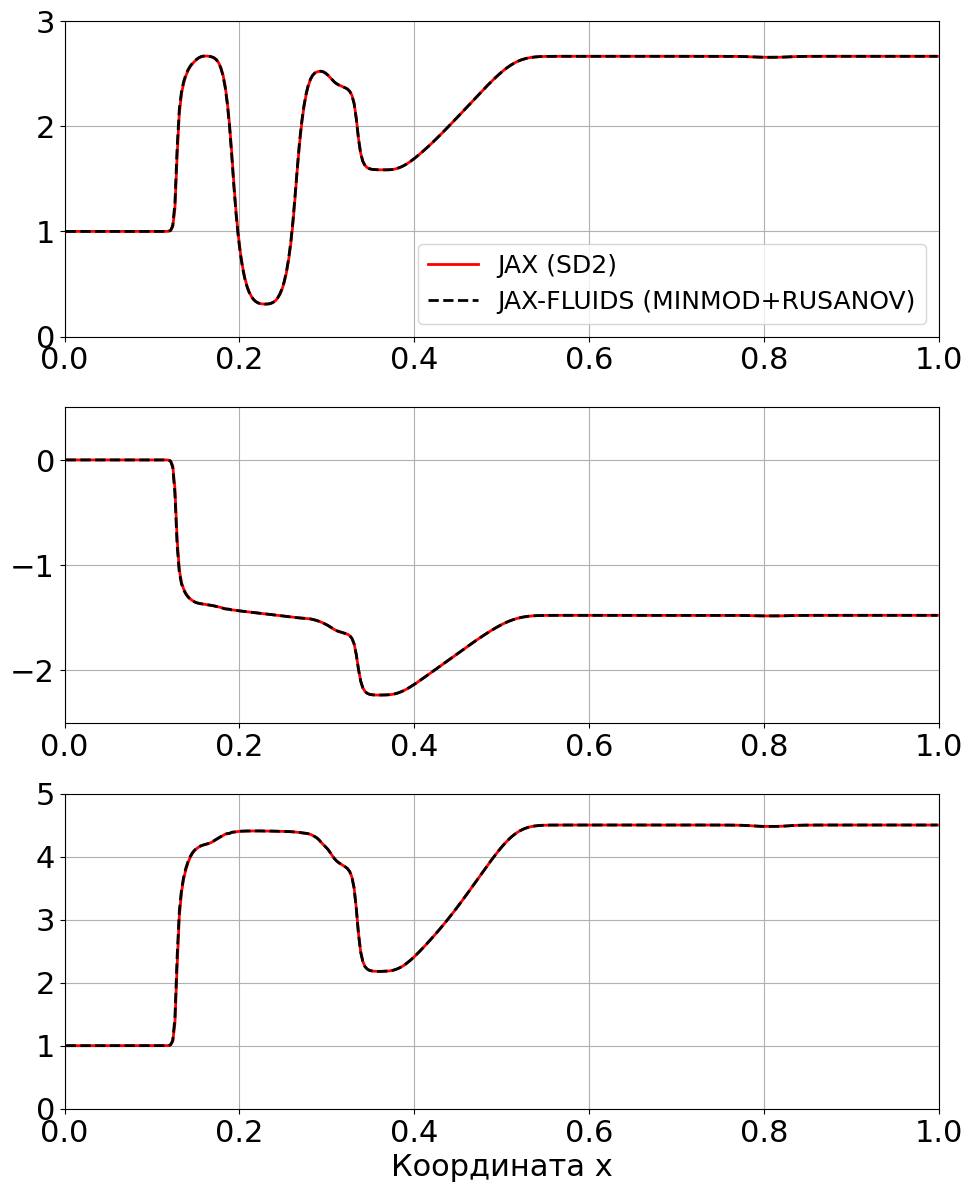

In [18]:
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt

# Ищем последний файл
h5_files = sorted(glob.glob("./results/**/*.h5", recursive=True))
last_file = h5_files[-1]

with h5py.File(last_file, "r") as f:
    # Используем правильные ключи для JAXFLUIDS
    x_jf = np.array(f["domain/gridX"]).flatten()
    rho_jf = np.array(f["primitives/density"]).flatten()
    u_jf = np.array(f["primitives/velocity"]).flatten()
    p_jf = np.array(f["primitives/pressure"]).flatten()

# Вытаскиваем ваш последний временной слой
rho_my = rho_num[-1]
u_my = u_num[-1]
p_my = p_num[-1]

fig, axes = plt.subplots(3, 1, figsize=(10, 12)) #, sharex=True
fig.tight_layout(pad=3.0)

# График плотности
axes[0].plot(x_num, rho_my, 'r-', lw=2, label='JAX (SD2)')
axes[0].plot(x_jf, rho_jf, 'k--', lw=2, label='JAX-FLUIDS (MINMOD+RUSANOV)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0.0, 3.0)
# axes[0].set_ylabel('Density')
axes[0].tick_params(axis='both', labelsize=22)
axes[0].grid(True)
axes[0].legend(prop={'size': 18})

# График скорости
axes[1].plot(x_num, u_my, 'r-', lw=2)
axes[1].plot(x_jf, u_jf, 'k--', lw=2)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-2.5, 0.5) # Подогнано под масштаб картинки
# axes[1].set_ylabel('Velocity')
axes[1].tick_params(axis='both', labelsize=22)
axes[1].grid(True)

# График давления
axes[2].plot(x_num, p_my, 'r-', lw=2)
axes[2].plot(x_jf, p_jf, 'k--', lw=2)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0.0, 5.0)  # Подогнано под масштаб картинки
# axes[2].set_ylabel('Pressure')
axes[2].set_xlabel('Координата x', fontsize=22)
axes[2].tick_params(axis='both', labelsize=22)
axes[2].grid(True)

plt.show()